In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import glob
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import cv2
import tf2onnx
import matplotlib.pyplot as plt
import onnx
# check that we are using gpu
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 15
AUTOTUNE    = tf.data.AUTOTUNE

IMAGE_PATH = r"C:\Projects\pupil_detection\pupil_detection-main\PythonFiles\Media\images" # has to be full path for some reason
MASK_PATH  = r"C:\Projects\pupil_detection\pupil_detection-main\PythonFiles\Media\masks" # use full path 

# Get list of image files
image_files = sorted(glob.glob(os.path.join(IMAGE_PATH, "*.png")))
print("Number of image files:", len(image_files))

# Create corresponding mask paths
image_paths = []
mask_paths  = []

for img_file in image_files:
    filename = os.path.basename(img_file)  # e.g., "12.png"
    mask_file = os.path.join(MASK_PATH, filename)
    if os.path.exists(mask_file):  # ensure the mask exists
        image_paths.append(img_file)
        mask_paths.append(mask_file)
    else:
        print(f"Mask not found for image: {filename}")
image_paths = image_paths[:500000]  # limit to 1000 images
mask_paths  = mask_paths[:500000]   # limit to 1000 masks
# Train/val split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, shuffle=True, random_state=42
)

def load_and_preprocess(img_path, mask_path):
    # Read image
    img  = tf.io.read_file(img_path)
    img  = tf.image.decode_png(img, channels=1)
    img  = tf.image.convert_image_dtype(img, tf.float32)
    img  = tf.image.resize(img, IMG_SIZE)

    # Read mask
    m   = tf.io.read_file(mask_path)
    m   = tf.image.decode_png(m, channels=1)
    m   = tf.image.convert_image_dtype(m, tf.float32)
    m   = tf.image.resize(m, IMG_SIZE)

    return img, m

Number of image files: 357409


In [3]:
train_ds = (tf.data.Dataset
             .from_tensor_slices((train_imgs, train_masks))
             .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
             .cache() # caches to RAM 
             .shuffle(buffer_size=len(train_imgs))
             .batch(BATCH_SIZE)
             .prefetch(AUTOTUNE))


val_ds = (
    tf.data.Dataset
      .from_tensor_slices((val_imgs, val_masks))
      .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
)


In [4]:
def build_seg_model(input_shape=(128, 128, 1)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D(2)(x)        
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)        
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)  
    x = layers.MaxPooling2D(2)(x)                                     

    x = layers.UpSampling2D(2)(x) 
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x) 
    x = layers.UpSampling2D(2)(x) 
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)       
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)       

    # Output layer
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="SegNet")

def build_seg_model_lite(input_shape=(128,128,1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D(2)(x)        
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)        
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)          

    # Decoder
    x = layers.UpSampling2D(2)(x) 
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)       
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D(2)(x)      

    # Output mask
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="SegNetLite")

In [5]:
# from tensorflow.keras.losses import Dice
# use gpu 

model = build_seg_model_lite()
print(tf.config.list_physical_devices('GPU'))
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
             ]
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6
)
save_best = tf.keras.callbacks.ModelCheckpoint(
    "best_model6.keras", save_best_only=True, monitor='val_loss', mode='min'
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr, save_best],
    verbose=1
)

# 7) Example: evaluate on validation set
results = model.evaluate(val_ds)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/15
8936/8936 [==============================] - 560s 23ms/step - loss: 0.0682 - accuracy: 0.9689 - val_loss: 0.0441 - val_accuracy: 0.9782 - lr: 0.0010
Epoch 2/15
8936/8936 [==============================] - 151s 17ms/step - loss: 0.0407 - accuracy: 0.9795 - val_loss: 0.0380 - val_accuracy: 0.9805 - lr: 0.0010
Epoch 3/15
8936/8936 [==============================] - 134s 15ms/step - loss: 0.0370 - accuracy: 0.9807 - val_loss: 0.0365 - val_accuracy: 0.9806 - lr: 0.0010
Epoch 4/15
8936/8936 [==============================] - 124s 14ms/step - loss: 0.0351 - accuracy: 0.9813 - val_loss: 0.0345 - val_accuracy: 0.9815 - lr: 0.0010
Epoch 5/15
8936/8936 [==============================] - 121s 13ms/step - loss: 0.0339 - accuracy: 0.9816 - val_loss: 0.0344 - val_accuracy: 0.9815 - lr: 0.0010
Epoch 6/15
8936/8936 [==============================] - 125s 14ms/step - loss: 0.0330 - accuracy: 0.9819 - val_loss: 0.0325 - val_acc

1/1 [==============================] - 0s 48ms/step


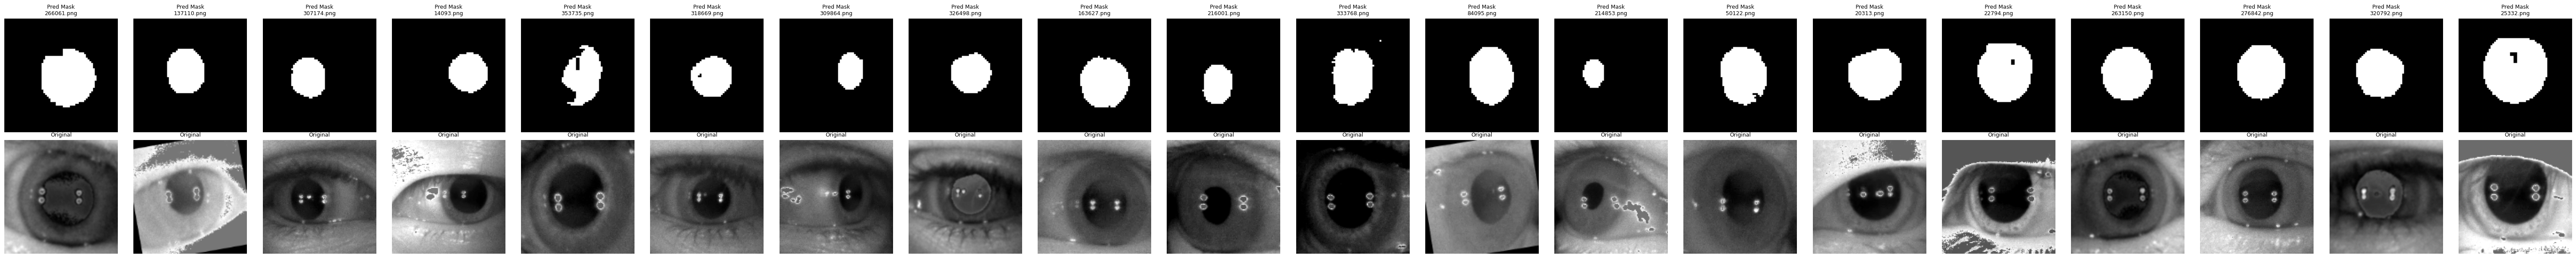

In [6]:
#inference 
def predict_mask(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img = img.reshape((1, *IMG_SIZE, 1)) 

    pred_mask = model.predict(img)
    pred_mask = (pred_mask > 0.5).astype("uint8")  
    return pred_mask[0].squeeze() 

N = 20
fig, axes = plt.subplots(2, N, figsize=(3 * N, 6))

for i in range(N):
    # Paths and data
    img_path = train_imgs[i]
    mask_pred = predict_mask(img_path)            
    img_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_orig = cv2.resize(img_orig, (128, 128))   

    # Top row: predicted mask
    ax = axes[0, i]
    ax.imshow(mask_pred, cmap='gray')
    ax.set_title(f"Pred Mask\n{os.path.basename(img_path)}", fontsize=9)
    ax.axis('off')

    # Bottom row: original image
    ax = axes[1, i]
    ax.imshow(img_orig, cmap='gray')
    ax.set_title("Original", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:

def overlay_mask(image_path, mask):
    # 1) load & resize gray
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)

    # 2) make it BGR
    img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # 3) boolean mask of shape (H,W)
    mask_bool = mask.astype(bool)

    # 4) overlay: copy original, then for each (i,j) where mask is True, set [B,G,R]=255
    overlay = img_bgr.copy()
    overlay[mask_bool, :] = (255, 255, 255)

    return overlay

num_pics = len(train_imgs)  
window_name = "Pupil Segmentation"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

for img_path in train_imgs:
    # 1) predict and overlay
    mask_pred = predict_mask(img_path)         
    overlaid  = overlay_mask(img_path, mask_pred)

    # 2) display in the same window
    cv2.imshow(window_name, overlaid)

    # 3) wait ~30ms between frames; exit on 'q'
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

# clean up
cv2.destroyWindow(window_name)

1/1 [==============================] - 0s 21ms/step


In [9]:
# save the model
model.save("mask_model7.keras")
# convert to ONNX

input_signature = [tf.TensorSpec([None, 128, 128, 1], tf.float32, name="input")]
model = tf.keras.models.load_model("mask_model7.keras")
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature, opset=13)
onnx.save(onnx_model, "model7.onnx")
